In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import *
import matplotlib.pyplot as plt

### Zadanie 2

In [2]:
iris = load_iris()
X_i = iris.data
y_i = iris.target
X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(X_i, y_i, test_size=0.2, stratify=y_i, random_state=42)
k = np.arange(1,21)
scores = {}
for x in k:
    model = KNeighborsClassifier(n_neighbors=x)
    scores[x] = np.mean(cross_val_score(model, X_i_train, y_i_train, cv=5, scoring='accuracy'))

print(f'Optymalne k: {max(scores, key=scores.get)}')

Optymalne k: 6


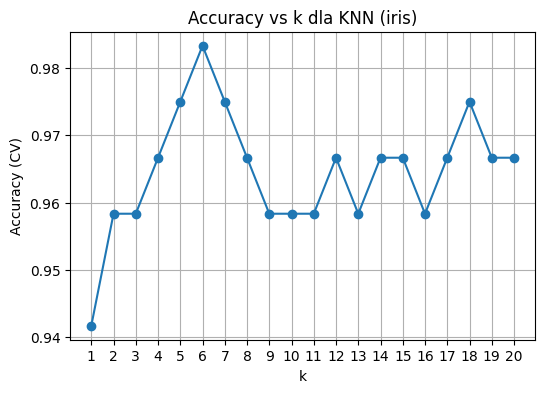

In [3]:
plt.figure(figsize=(6,4))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy (CV)')
plt.title('Accuracy vs k dla KNN (iris)')
plt.xticks(k)
plt.grid(True)
plt.show()

### Zadanie 6

In [4]:
bc = load_breast_cancer()
X = bc.data
y = bc.target
feature_names = bc.feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {'Decision Tree': DecisionTreeClassifier(max_depth=5),
          'Random Forest': RandomForestClassifier(max_depth=5)}
feats = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    feats[name] = model.feature_importances_


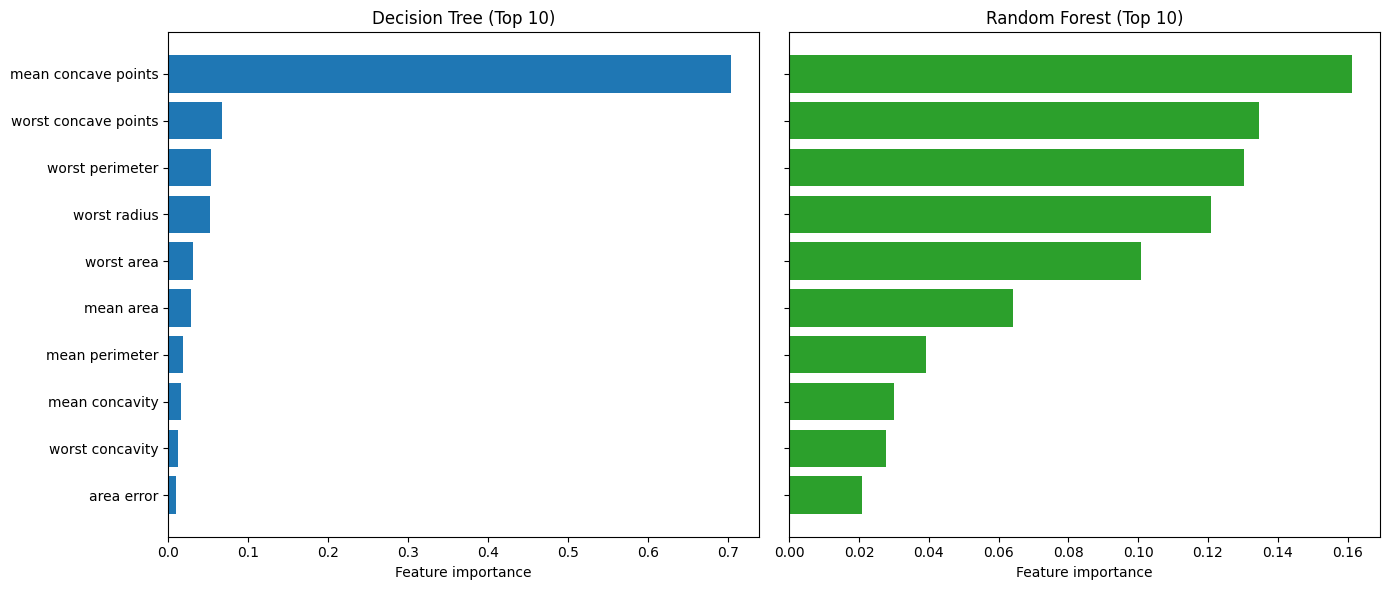

In [5]:
dt_importances = feats['Decision Tree']
dt_idx_sorted = np.argsort(dt_importances)[::-1][:10]
dt_top_importances = dt_importances[dt_idx_sorted]
dt_top_names = feature_names[dt_idx_sorted]

rf_importances = feats['Random Forest']
rf_idx_sorted = np.argsort(rf_importances)[::-1][:10]
rf_top_importances = rf_importances[rf_idx_sorted]
rf_top_names = feature_names[rf_idx_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].barh(range(10), dt_top_importances[::-1], color='tab:blue')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(dt_top_names[::-1])
axes[0].set_xlabel('Feature importance')
axes[0].set_title('Decision Tree (Top 10)')

axes[1].barh(range(10), rf_top_importances[::-1], color='tab:green')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(rf_top_names[::-1])
axes[1].set_xlabel('Feature importance')
axes[1].set_title('Random Forest (Top 10)')

plt.tight_layout()
plt.show()

* W pojedynczym drzewie decyzyjnym dominuje jedna cecha. Dzieje się tak, ponieważ na jednym liściu, drzewo podejmuje decyzje na podstawie jednej cechy na raz. W takim przypadku, każdy kolejny liść, który determinuje ostateczny wynik będzie miał mniejsze znaczenie.
* W random forest rozkład cech jest bardziej wyważony. Ten model przyjmuje, że każde z drzew podejmuje decyzje na bazie 70-80% cech i następuje majority voting. Ważność cech jest więc bardziej uśredniona.

### Zadanie 8

In [6]:
models = {'Decision Tree': DecisionTreeClassifier(max_depth=5),
          'Random Forest': RandomForestClassifier(max_depth=5),
          'KNN': KNeighborsClassifier(n_neighbors=5)}
scores = {}
for key, value in models.items():
    cv_scores = cross_val_score(value, X_i_train, y_i_train, cv=5, scoring='accuracy')
    scores[key] = {'mean': np.mean(cv_scores), 'std': np.std(cv_scores)}



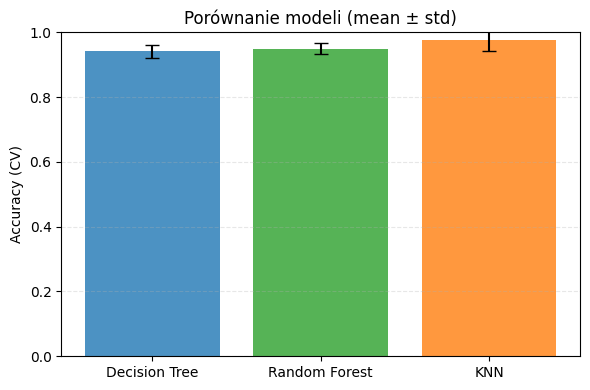

In [7]:
model_names = list(scores.keys())
means = [scores[m]['mean'] for m in model_names]
stds  = [scores[m]['std']  for m in model_names]
x = np.arange(len(model_names))

plt.figure(figsize=(6, 4))
plt.bar(
    x,
    means,
    yerr=stds,
    capsize=5,
    alpha=0.8,
    color=['tab:blue', 'tab:green', 'tab:orange']
)
plt.xticks(x, model_names)
plt.ylabel('Accuracy (CV)')
plt.title('Porównanie modeli (mean ± std)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()